In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM,Bidirectional,GRU
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import RMSprop
import datetime
import io
import itertools
# import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

import sys
import os
# Obtener la ruta del directorio actual
os.chdir('..')
current_dir = os.getcwd()
print(current_dir)

# Construir la ruta relativa al directorio que quieres agregar
relative_dir = os.path.join(current_dir, 'mis_pkgs/')

# Agregar la ruta relativa al sys.path
sys.path.insert(0, relative_dir)

from MIOPATIA_db import DB_management as db 


c:\Users\rgadea\AppData\Local\miniconda3\envs\tensorflow_gpu_2024\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


i:\nuevas_investigaciones_alimentos_2024


In [2]:
numero_muestras=401
numero_clases=2

Voy a quedarme con los 50 atunes P1 para obtener conjunto de training y validacion

In [3]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Add, Activation, Concatenate, Conv2D, Dropout 
from tensorflow.keras.layers import Flatten, Input, GlobalAveragePooling2D, MaxPooling2D
import tensorflow.keras.backend as K

__version__ = '0.0.1'


def SqueezeNet(input_shape, nb_classes, use_bypass=False, dropout_rate=None, compression=1.0):
    """
    Creating a SqueezeNet of version 1.0
    
    Arguments:
        input_shape  : shape of the input images e.g. (224,224,3)
        nb_classes   : number of classes
        use_bypass   : if true, bypass connections will be created at fire module 3, 5, 7, and 9 (default: False)
        dropout_rate : defines the dropout rate that is accomplished after last fire module (default: None)
        compression  : reduce the number of feature-maps (default: 1.0)
        
    Returns:
        Model        : Keras model instance
    """
    
    input_img = Input(shape=input_shape)

    x = Conv2D(int(96*compression), (7,7), activation='relu', strides=(2,2), padding='same', name='conv1')(input_img)

    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool1')(x)
    
    x = create_fire_module(x, int(16*compression), name='fire2')
    x = create_fire_module(x, int(16*compression), name='fire3', use_bypass=use_bypass)
    x = create_fire_module(x, int(32*compression), name='fire4')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool4')(x)
    
    x = create_fire_module(x, int(32*compression), name='fire5', use_bypass=use_bypass)
    x = create_fire_module(x, int(48*compression), name='fire6')
    x = create_fire_module(x, int(48*compression), name='fire7', use_bypass=use_bypass)
    x = create_fire_module(x, int(64*compression), name='fire8')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool8')(x)
    
    x = create_fire_module(x, int(64*compression), name='fire9', use_bypass=use_bypass)

    if dropout_rate:
        x = Dropout(dropout_rate)(x)
        
    x = output(x, nb_classes)

    return Model(inputs=input_img, outputs=x)


def SqueezeNet_11(input_shape, nb_classes, dropout_rate=None, compression=1.0):
    """
    Creating a SqueezeNet of version 1.1
    
    2.4x less computation over SqueezeNet 1.0 implemented above.
    
    Arguments:
        input_shape  : shape of the input images e.g. (224,224,3)
        nb_classes   : number of classes
        dropout_rate : defines the dropout rate that is accomplished after last fire module (default: None)
        compression  : reduce the number of feature-maps
        
    Returns:
        Model        : Keras model instance
    """
    
    input_img = Input(shape=input_shape)

    x = Conv2D(int(64*compression), (3,3), activation='relu', strides=(2,2), padding='same', name='conv1')(input_img)

    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool1')(x)
    
    x = create_fire_module(x, int(16*compression), name='fire2')
    x = create_fire_module(x, int(16*compression), name='fire3')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool3')(x)
    
    x = create_fire_module(x, int(32*compression), name='fire4')
    x = create_fire_module(x, int(32*compression), name='fire5')
    
    x = MaxPooling2D(pool_size=(3,3), strides=(2,2), name='maxpool5')(x)
    
    x = create_fire_module(x, int(48*compression), name='fire6')
    x = create_fire_module(x, int(48*compression), name='fire7')
    x = create_fire_module(x, int(64*compression), name='fire8')
    x = create_fire_module(x, int(64*compression), name='fire9')

    if dropout_rate:
        x = Dropout(dropout_rate)(x)
    
    # Creating last conv10
    x = output(x, nb_classes )

    return Model(inputs=input_img, outputs=x)


def output(x, nb_classes):
    x = Conv2D(nb_classes, (1,1), strides=(1,1), padding='valid', name='conv10')(x)
    x = GlobalAveragePooling2D(name='avgpool10')(x)
    x = Activation("softmax", name='softmax')(x)
    return x


def create_fire_module(x, nb_squeeze_filter, name, use_bypass=False):
    """
    Creates a fire module
    
    Arguments:
        x                 : input
        nb_squeeze_filter : number of filters of squeeze. The filtersize of expand is 4 times of squeeze
        use_bypass        : if True then a bypass will be added
        name              : name of module e.g. fire123
    
    Returns:
        x                 : returns a fire module
    """
    
    nb_expand_filter = 4 * nb_squeeze_filter
    squeeze    = Conv2D(nb_squeeze_filter,(1,1), activation='relu', padding='same', name='%s_squeeze'%name)(x)
    expand_1x1 = Conv2D(nb_expand_filter, (1,1), activation='relu', padding='same', name='%s_expand_1x1'%name)(squeeze)
    expand_3x3 = Conv2D(nb_expand_filter, (3,3), activation='relu', padding='same', name='%s_expand_3x3'%name)(squeeze)
    
    axis = get_axis()
    x_ret = Concatenate(axis=axis, name='%s_concatenate'%name)([expand_1x1, expand_3x3])
    
    if use_bypass:
        x_ret = Add(name='%s_concatenate_bypass'%name)([x_ret, x])
        
    return x_ret


def get_axis():
    axis = -1 if K.image_data_format() == 'channels_last' else 1
    return axis


In [4]:
contador_buenos=0
contador_malos=0
filename = "COPIA_PANDAS/hdf_lomosAgilent_trainval_filtrado_def_good_ampliado_mas_meditado.hdf"
with pd.HDFStore(filename,complib="zlib",complevel=4) as hdf_db:
    pre_p_e1  = hdf_db.get('data/pollos_estado')
    pre_p_e1 = pre_p_e1.loc[pre_p_e1['Pollo'] != 0]
    # p_e =pre_p_e1.drop_duplicates(subset = ['Pollo', 'Medida'],  keep = 'last').reset_index(drop = True)
    t    = hdf_db.get('data/tabla')
    X_train1=np.zeros((pre_p_e1.shape[0],int((numero_muestras-1)),2))
    X_train2=np.zeros((pre_p_e1.shape[0],int((numero_muestras-1)),2))    
    X_normalized=np.zeros((pre_p_e1.shape[0],int((numero_muestras-1)),2))
    y_train=np.zeros((pre_p_e1.shape[0],1))
    x=0
    for index, row in pre_p_e1.iterrows():   # El primer registro no se toma en cuenta porque es basura
        Primero = int(row['Primero'])
        Ultimo  = int(row['Ultimo'])
        estado  = int(row['Estado'])
        #print(Primero)
        #print(Ultimo)
        #print(estado)
        if numero_clases==2:
            if estado == 0 or estado== 1:
                target = 0
                contador_buenos=contador_buenos+1   
            else:
                target = 1
                contador_malos=contador_malos+1
        else:
            target=estado
        pepito=np.array(t.iloc[Primero:Ultimo+1])
        #print(pepito[:400,3:6].shape)

        X_train1[x,:,0]=pepito[0:400,9]
        X_train1[x,:,1]=-pepito[0:400,10]    
        X_train2[x,:,0]=1/pepito[0:400,5]
        X_train2[x,:,1]=1/pepito[0:400,6]        
       # X_train[x]=pepito[50:400,9:11] 
        # Normaliza tus datos al rango [0, 1]
       # X_normalized[x] = (X_train[x] - X_train[x].min(axis=0)) / (X_train[x].max(axis=0) - X_train[x].min(axis=0))
        #X_train[x]=X_train[x].reshape(X_train[x].shape[0],-1)
        #print(X_train[x][0:4,:])       
        y_train[x]=target
        y_train_to_categorical = to_categorical(y_train)
        x=x+1


# print(X_train.shape)
# print(y_train_to_categorical.shape)
# #print(X_train[0:4,:,:])
# #print(X_train[1][0:4][:])
# print(y_train[1:20])
# print(y_train_to_categorical[1:20])
# # #Aqui filtrariamos si hay filas que no nos interesan. En este caso dejo pasar todos los casos
# print(p_e)
# # X_train_filtrado = X_train[2:][:,:]
# # y_train_filtrado = y_train[2:]
X_train_filtrado1 = X_train1
X_train_filtrado2 = X_train2
#y_train_filtrado = y_train
y_train_filtrado = y_train_to_categorical


filename = "COPIA_PANDAS/hdf_lomosAgilent_test_filtrado_def_good.hdf"
with pd.HDFStore(filename,complib="zlib",complevel=4) as hdf_db:
    pre_p_e1  = hdf_db.get('data/pollos_estado')
    pre_p_e1 = pre_p_e1.loc[pre_p_e1['Pollo'] != 0]
    pre_p_e1 =pre_p_e1.drop_duplicates(subset = ['Pollo', 'Medida'],  keep = 'last').reset_index(drop = True)
    t    = hdf_db.get('data/tabla')
    X_test1=np.zeros((pre_p_e1.shape[0],int((numero_muestras-1)),2))
    X_test2=np.zeros((pre_p_e1.shape[0],int((numero_muestras-1)),2))
    X_normalized_test=np.zeros((pre_p_e1.shape[0],int((numero_muestras-1)),2))
    y_test=np.zeros((pre_p_e1.shape[0],1))
    x=0
    for index, row in pre_p_e1.iterrows():   # El primer registro no se toma en cuenta porque es basura
        Primero = int(row['Primero'])
        Ultimo  = int(row['Ultimo'])
        estado  = int(row['Estado'])
        #print(Primero)
        #print(Ultimo)
        #print(estado)
        if numero_clases==2:
            if estado == 0 or estado== 1:
                target = 0
            else:
                target = 1

        else:
            target=estado
        pepito=np.array(t.iloc[Primero:Ultimo+1])
        # #print(pepito.shape)
        
        #X_test[x]=pepito[50:400,9:11]
        X_test1[x,:,0]=pepito[0:400,9]    
        X_test1[x,:,1]=-pepito[0:400,10]          
        X_test2[x,:,0]=1/pepito[0:400,5]    
        X_test2[x,:,1]=1/pepito[0:400,6]            
        # Normaliza tus datos al rango [0, 1]
        #X_normalized_test[x] = (X_test[x] - X_test[x].min(axis=0)) / (X_test[x].max(axis=0) - X_test[x].min(axis=0))

        #print(X_train[x][0:4,:])       
        y_test[x]=target
        y_test_to_categorical = to_categorical(y_test)
        x=x+1


# print(X_train.shape)
# print(y_train_to_categorical.shape)
# #print(X_train[0:4,:,:])
# #print(X_train[1][0:4][:])
# print(y_train[1:20])
# print(y_train_to_categorical[1:20])
# # #Aqui filtrariamos si hay filas que no nos interesan. En este caso dejo pasar todos los casos
# print(p_e)
# # X_train_filtrado = X_train[2:][:,:]
# # y_train_filtrado = y_train[2:]
X_test_filtrado1 = X_test1
X_test_filtrado2 = X_test2
#y_train_filtrado = y_train
y_test_filtrado = y_test_to_categorical

print(X_test_filtrado1.shape)
print(y_test_filtrado.shape)
# print(X_train_filtrado[0][:,:])
# # # Vamos a normalizar o escalar los datos
# concatenamos train y test
#X_total=np.concatenate((X_train_filtrado,X_test_filtrado),axis=0)
#scaler = MinMaxScaler(feature_range=(0, 1))
#data_2d_test = X_total.reshape(-1, X_total.shape[-1])



# X_test_def=normalized_data_2d_test.reshape(X_test_filtrado.shape) 


# la alternativa es normalizar con el total
# X_test_def=normalized_data_2d_test.reshape(X_test_filtrado.shape) 

y_test_def=y_test_filtrado # los valores ya estaban normalizados
#print(X_test_def[0])





# print(X_train_filtrado.shape)
# print(y_train_filtrado.shape)
# print(X_train_filtrado[0][:,:])
# # # Vamos a normalizar o escalar los datos
scaler1 = MinMaxScaler()
scaler2 = MinMaxScaler()
print(X_train_filtrado1.shape)
print(X_test_filtrado2.shape)

data1=np.concatenate((X_train_filtrado1,X_test_filtrado1),axis=0) 
print(data1.shape)
data2=np.concatenate((X_train_filtrado2,X_test_filtrado2),axis=0)
data_total1 =data1.reshape(-1, data1.shape[-1])
data_2d1 =X_train_filtrado1.reshape(-1, X_train_filtrado1.shape[-1])
normalized_data_total1 = scaler1.fit_transform(data_total1)
data_2d_test1 = X_test_filtrado1.reshape(-1, X_test_filtrado1.shape[-1])
normalized_data_2d_test1 = scaler1.transform(data_2d_test1) 
normalized_data_2d1 = scaler1.transform(data_2d1)
X_train_Normalizado1=normalized_data_2d1.reshape(X_train_filtrado1.shape[0],int((numero_muestras-1)),-1)
X_test_def1=normalized_data_2d_test1.reshape(X_test_filtrado1.shape[0],int((numero_muestras-1)),-1) 


data_total2 =data2.reshape(-1, data2.shape[-1])
data_2d2 =X_train_filtrado2.reshape(-1, X_train_filtrado2.shape[-1])
normalized_data_total2 = scaler2.fit_transform(data_total2)
data_2d_test2 = X_test_filtrado2.reshape(-1, X_test_filtrado2.shape[-1])
normalized_data_2d_test2 = scaler2.transform(data_2d_test2) 
normalized_data_2d2 = scaler2.transform(data_2d2)
X_train_Normalizado2=normalized_data_2d2.reshape(X_train_filtrado2.shape[0],int((numero_muestras-1)),-1)
X_test_def2=normalized_data_2d_test2.reshape(X_test_filtrado2.shape[0],int((numero_muestras-1)),-1) 


#para recurrentes
#X_train_Normalizado=normalized_data_2d.reshape(X_train_filtrado.shape) #para recurrentes
#para densas

y_train_Normalizado=y_train_filtrado # los valores ya estaban normalizados
print(y_train_Normalizado.shape)
print(normalized_data_2d1.shape)
print(X_train_Normalizado1.shape)
print(normalized_data_2d2.shape)
print(X_train_Normalizado2.shape)

#print(X_normalized.shape)

print("Buenos: ",contador_buenos)
print("Malos: ",contador_malos)

(39, 400, 2)
(39, 2)
(853, 400, 2)
(39, 400, 2)
(892, 400, 2)
(853, 2)
(341200, 2)
(853, 400, 2)
(341200, 2)
(853, 400, 2)
Buenos:  602
Malos:  251


(853, 400, 2)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


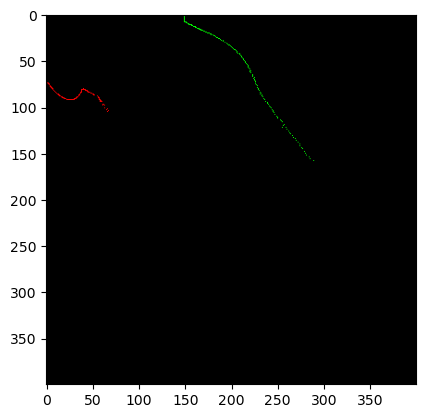

In [5]:

# Convierte las coordenadas normalizadas a índices de píxeles
pixel_coords1 = (X_train_Normalizado1 * int((numero_muestras-1))-1).astype(int)  # Asume que quieres una imagen de 400x400
pixel_coords2 = (X_train_Normalizado2 * int((numero_muestras-1))-1).astype(int)  # Asume que quieres una imagen de 400x400

print(pixel_coords1.shape)   
# Crea una imagen en blanco de 400x400
image = np.zeros((pixel_coords1.shape[0],int((numero_muestras-1)), int((numero_muestras-1)),3))


# Coloca un pixel negro en cada coordenada
for i in range (pixel_coords1.shape[0]):
    for x, y in pixel_coords1[i]:
        image[i,y, x,0] =255  # Usa 'y, x' en lugar de 'x, y' porque las imágenes se indexan por 'fila, columna'
# Coloca un pixel negro en cada coordenada
for i in range (pixel_coords2.shape[0]):
    for x, y in pixel_coords2[i]:
        image[i,y, x,1] =255 
# Muestra la imagen
#image = np.flip(image, axis=1)
plt.imshow(image[108], cmap='gray')
plt.show()

In [6]:
# Encuentra los valores mínimo y máximo en la imagen
min_value = np.amin(image[108])
max_value = np.amax(image[108])

# Encuentra las coordenadas de los valores mínimo y máximo
min_coords = np.where(image[108] == min_value)
max_coords = np.where(image[108] == max_value)

# min_coords y max_coords son tuplas de arrays, donde el primer array contiene las coordenadas y y el segundo array contiene las coordenadas x
# Encuentra el punto más arriba (menor valor de y) para cada conjunto de coordenadas
min_y = np.amin(min_coords[0])
min_x = min_coords[1][np.where(min_coords[0] == min_y)][0]

max_y = np.amin(max_coords[0])
max_x = max_coords[1][np.where(max_coords[0] == max_y)][0]

print(f"El valor mínimo es {min_value} y se encuentra en las coordenadas ({min_x}, {min_y})")
print(f"El valor máximo es {max_value} y se encuentra en las coordenadas ({max_x}, {max_y})")

El valor mínimo es 0.0 y se encuentra en las coordenadas (0, 0)
El valor máximo es 255.0 y se encuentra en las coordenadas (143, 0)


In [7]:
# filename = "COPIA_PANDAS/hdf_lomosAgilent_test_filtrado_def_good.hdf"
# with pd.HDFStore(filename,complib="zlib",complevel=4) as hdf_db:
#     pre_p_e1  = hdf_db.get('data/pollos_estado')
#     pre_p_e1 = pre_p_e1.loc[pre_p_e1['Pollo'] != 0]
#     pre_p_e1 =pre_p_e1.drop_duplicates(subset = ['Pollo', 'Medida'],  keep = 'last').reset_index(drop = True)
#     t    = hdf_db.get('data/tabla')
#     X_test1=np.zeros((pre_p_e1.shape[0],int((numero_muestras-1)*7/8),2))
#     X_test2=np.zeros((pre_p_e1.shape[0],int((numero_muestras-1)*7/8),2))
#     X_normalized_test=np.zeros((pre_p_e1.shape[0],int((numero_muestras-1)*7/8),2))
#     y_test=np.zeros((pre_p_e1.shape[0],1))
#     x=0
#     for index, row in pre_p_e1.iterrows():   # El primer registro no se toma en cuenta porque es basura
#         Primero = int(row['Primero'])
#         Ultimo  = int(row['Ultimo'])
#         estado  = int(row['Estado'])
#         #print(Primero)
#         #print(Ultimo)
#         #print(estado)
#         if numero_clases==2:
#             if estado == 0 or estado== 1:
#                 target = 0
#             else:
#                 target = 1

#         else:
#             target=estado
#         pepito=np.array(t.iloc[Primero:Ultimo+1])
#         # #print(pepito.shape)
        
#         #X_test[x]=pepito[50:400,9:11]
#         X_test1[x,:,0]=pepito[50:400,9]    
#         X_test1[x,:,1]=-pepito[50:400,10]          
#         X_test2[x,:,0]=1/pepito[50:400,5]    
#         X_test2[x,:,1]=1/pepito[50:400,6]            
#         # Normaliza tus datos al rango [0, 1]
#         #X_normalized_test[x] = (X_test[x] - X_test[x].min(axis=0)) / (X_test[x].max(axis=0) - X_test[x].min(axis=0))

#         #print(X_train[x][0:4,:])       
#         y_test[x]=target
#         y_test_to_categorical = to_categorical(y_test)
#         x=x+1


# # print(X_train.shape)
# # print(y_train_to_categorical.shape)
# # #print(X_train[0:4,:,:])
# # #print(X_train[1][0:4][:])
# # print(y_train[1:20])
# # print(y_train_to_categorical[1:20])
# # # #Aqui filtrariamos si hay filas que no nos interesan. En este caso dejo pasar todos los casos
# # print(p_e)
# # # X_train_filtrado = X_train[2:][:,:]
# # # y_train_filtrado = y_train[2:]
# X_test_filtrado1 = X_test1
# X_test_filtrado2 = X_test2
# #y_train_filtrado = y_train
# y_test_filtrado = y_test_to_categorical

# print(X_test_filtrado1.shape)
# print(y_test_filtrado.shape)
# # print(X_train_filtrado[0][:,:])
# # # # Vamos a normalizar o escalar los datos
# # concatenamos train y test
# #X_total=np.concatenate((X_train_filtrado,X_test_filtrado),axis=0)
# #scaler = MinMaxScaler(feature_range=(0, 1))
# #data_2d_test = X_total.reshape(-1, X_total.shape[-1])
# data_2d_test1 = X_test_filtrado1.reshape(-1, X_test_filtrado1.shape[-1])
# normalized_data_2d_test1 = scaler1.transform(data_2d_test1)

# data_2d_test2 = X_test_filtrado2.reshape(-1, X_test_filtrado2.shape[-1])
# normalized_data_2d_test2 = scaler2.transform(data_2d_test2)


# # X_test_def=normalized_data_2d_test.reshape(X_test_filtrado.shape) 
# X_test_def1=normalized_data_2d_test1.reshape(X_test_filtrado1.shape[0],int((numero_muestras-1)*7/8),-1) 
# X_test_def2=normalized_data_2d_test2.reshape(X_test_filtrado2.shape[0],int((numero_muestras-1)*7/8),-1) 
# # la alternativa es normalizar con el total
# # X_test_def=normalized_data_2d_test.reshape(X_test_filtrado.shape) 

# y_test_def=y_test_filtrado # los valores ya estaban normalizados
# #print(X_test_def[0])

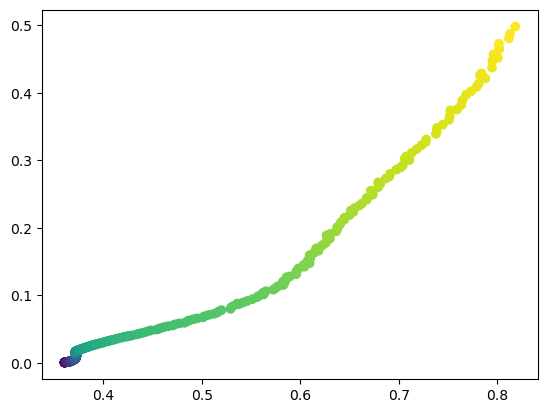

In [8]:
# Convierte las coordenadas normalizadas a índices de píxeles
import matplotlib.pyplot as plt
pixel_coords_test1 = (X_test_def1 * int((numero_muestras-1)*7/8)-1).astype(int)  # Asume que quieres una imagen de 400x400
pixel_coords_test2 = (X_test_def2 * int((numero_muestras-1)*7/8)-1).astype(int)  # Asume que quieres una imagen de 400x400
x_coords = X_test_def2[15, :, 0]
y_coords = X_test_def2[15, :, 1]
# Crea una escala de colores basada en el índice de la segunda coordenada
colors = np.arange(len(x_coords))
# Crea un gráfico de dispersión con una escala de colores
plt.scatter(x_coords, y_coords, c=colors, cmap='viridis')

plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


(39, 400, 2)
(39, 400, 400, 3)


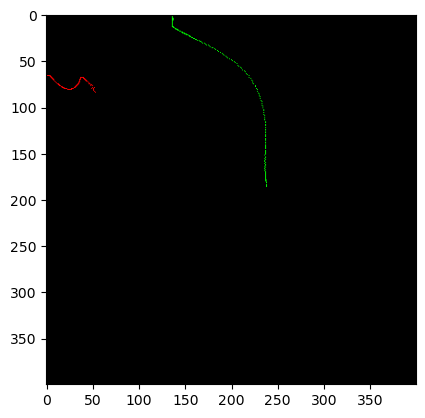

In [9]:

#pixel_coords_test[:,:,0]=1/pixel_coords_test[:,:,0]
#pixel_coords_test[:,:,1]=1/pixel_coords_test[:,:,1]
print(pixel_coords_test1.shape)   
# Crea una imagen en blanco de 400x400
image_test = np.zeros((pixel_coords_test1.shape[0],int((numero_muestras-1)),int((numero_muestras-1)),3))
print(image_test.shape)

# Coloca un pixel negro en cada coordenada
for i in range (pixel_coords_test1.shape[0]):
    for x, y in pixel_coords_test1[i]:
        image_test[i,y, x,0] = 255  # Usa 'y, x' en lugar de 'x, y' porque las imágenes se indexan por 'fila, columna'



# Coloca un pixel negro en cada coordenada
for i in range (pixel_coords_test2.shape[0]):
    for x, y in pixel_coords_test2[i]:
        #if (x<351 and y<351):
        image_test[i,y, x,1] = 255 # Usa 'y, x' en lugar de 'x, y' porque las imágenes se indexan por 'fila, columna'

# Muestra la imagen
plt.imshow(image_test[10], cmap='gray')
plt.show()

Vamos a hacer los conjuntos de entrenamiento validacion y test

In [10]:
# Divide el dataset en entrenamiento y temporal (test+validación)
# X_temp, X_test_def, y_temp, y_test_def = train_test_split(X_train_Normalizado, y_train_Normalizado, test_size=0.2, stratify=y_train_Normalizado, random_state=42)

# Divide el dataset temporal en validación y test
X_train_def, X_val_def, y_train_def, y_val_def = train_test_split(image, y_train_Normalizado, test_size=0.25, stratify=y_train_Normalizado, random_state=42)

# Ahora, X_train, X_val y X_test contienen los datos de entrada para los conjuntos de entrenamiento, validación y prueba, respectivamente.
# y_train, y_val y y_test contienen las clases correspondientes.

In [11]:
print(X_train_def.shape)
print(X_val_def.shape)
print(image_test.shape)
print(y_train_def.shape)
print(y_val_def.shape)
print(y_test_def.shape)

(639, 400, 400, 3)
(214, 400, 400, 3)
(39, 400, 400, 3)
(639, 2)
(214, 2)
(39, 2)


In [12]:
print(image_test[10,0:50,11:25,0])

[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0.

In [13]:
%load_ext tensorboard

#%tensorboard --logdir logs
#log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
#tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir, histogram_freq=1)

In [14]:
def plot_to_image(figure):
    """
    Converts the matplotlib plot specified by 'figure' to a PNG image and
    returns it. The supplied figure is closed and inaccessible after this call.
    """
    
    buf = io.BytesIO()
    
    # Use plt.savefig to save the plot to a PNG in memory.
    plt.savefig(buf, format='png')
    
    # Closing the figure prevents it from being displayed directly inside
    # the notebook.
    plt.close(figure)
    buf.seek(0)
    
    # Use tf.image.decode_png to convert the PNG buffer
    # to a TF image. Make sure you use 4 channels.
    image = tf.image.decode_png(buf.getvalue(), channels=4)
    
    # Use tf.expand_dims to add the batch dimension
    image = tf.expand_dims(image, 0)
    
    return image

In [15]:
def plot_confusion_matrix(cm, class_names):
    """
    Returns a matplotlib figure containing the plotted confusion matrix.
    
    Args:
       cm (array, shape = [n, n]): a confusion matrix of integer classes
       class_names (array, shape = [n]): String names of the integer classes
    """
    
    figure = plt.figure(figsize=(8, 8))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title("Confusion matrix")
    plt.colorbar()
    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)
    
    # Normalize the confusion matrix.
    cm = np.around(cm.astype('float') / cm.sum(axis=1)[:, np.newaxis], decimals=2)
    
    # Use white text if squares are dark; otherwise black.
    threshold = cm.max() / 2.
    threshold = 0.5
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        color = "red" if cm[i, j] > threshold else "black"
        plt.text(j, i, cm[i, j], horizontalalignment="center", color=color)
        
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    return figure

In [16]:
factor_aprendizaje=0.001
dimension_LSTM=50
dimension_dense1=50
dimension_dense2=20
algoritmo='rmsprop'
supermax=8*4
lossfunction='categorical_crossentropy'
def create_model():

    model = Sequential()
    # model.add(Bidirectional(GRU(dimension_LSTM, return_sequences=True, recurrent_regularizer='L2'),input_shape=(401, 8)))
    # # model.add(GRU(50, return_sequences=True))
    # model.add(GRU(50, return_sequences=False))
    # model.add(Dense(dimension_dense1, activation='tanh'))
    # model.add(Dense(dimension_dense2, activation='tanh'))
    # model.add(Dense(numero_clases, activation='softmax'))
    model.add(SqueezeNet_11(input_shape=(int((numero_muestras-1)),int((numero_muestras-1)), 3), nb_classes=2, dropout_rate=0.5, compression=1.0))
    # Instantiate RMSprop with a momentum
    rmsprop = RMSprop(learning_rate=factor_aprendizaje)
    rmsprop = RMSprop(learning_rate=factor_aprendizaje)
    model.compile(loss=lossfunction, optimizer=rmsprop, metrics=['accuracy'])
    #model.optimizer.lr=(factor_aprendizaje)
    return model

model=create_model()

In [17]:

experimento="LOMOS_Agilent_{}_clases_dense1_{}_dense2_{}_loss_{}_lr_{}_algoritmo_{}".format(numero_clases,dimension_LSTM,dimension_dense1,dimension_dense2,lossfunction,factor_aprendizaje,algoritmo)
logdir="./logs/defs/{}_{}".format(experimento,datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callback=tf.keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=1)
file_writer_cm = tf.summary.create_file_writer(logdir + '/cm')


In [18]:
if numero_clases==2:
    class_names=['Buenos', 'Malos']
else:
    class_names=['A', 'B+', 'B', 'B-','C']

In [19]:
def log_confusion_matrix(epoch, logs):
    
    # Use the model to predict the values from the test_images.
    y_pred = model.predict(image_test)
    #y_pred1=y_pred[:,-1]
    y_pred2=y_pred.argmax(axis=1)
    #y_pred2=np.where(y_pred>0,1,0)
    #y_pred2=y_pred2[:,-1]
    if numero_clases==2:
        classes = [0, 1]    
    else:

        classes = [0, 1, 2, 3, 4] 
    #classes = [0, 1]
    y_test_def2=np.argmax(y_test_def,axis=1)  
    #y_test_def2=np.where(y_test_def>0,1,0)
    cm=confusion_matrix(y_test_def2, y_pred2,labels=classes)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    figura = plot_confusion_matrix(cm, class_names=class_names)
    cm_image = plot_to_image(figura)
    
    # Log the confusion matrix as an image summary.
    with file_writer_cm.as_default():
        tf.summary.image("Confusion Matrix", cm_image, step=epoch)

In [20]:
cm_callback = tf.keras.callbacks.LambdaCallback(on_epoch_end=log_confusion_matrix)
print(y_train_Normalizado.shape)
print(y_val_def.shape)

(853, 2)
(214, 2)


In [21]:
# Crear un callback para guardar los mejores pesos
#checkpoint = tf.keras.callbacks.ModelCheckpoint('best_weights.h5', monitor='val_loss', verbose=1, save_best_only=True, mode='min')


In [22]:
early_stop=tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', min_delta=0, patience=200, verbose=2, mode='max', baseline=None, restore_best_weights=True)
model.fit(image, y_train_Normalizado, epochs=400, batch_size=100, callbacks=[tensorboard_callback,early_stop], validation_data=(image_test, y_test_def))
# Final evaluation of the model 
scores = model.evaluate(image_test, y_test_def, verbose=0)
print("Accuracy: %.2f%%" % (scores[1]*100))

Epoch 1/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.7169 - loss: 0.6636 - val_accuracy: 0.7436 - val_loss: 0.5696
Epoch 2/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.6989 - loss: 0.6182 - val_accuracy: 0.7436 - val_loss: 0.5706
Epoch 3/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.6845 - loss: 0.6276 - val_accuracy: 0.7436 - val_loss: 0.5898
Epoch 4/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7233 - loss: 0.5982 - val_accuracy: 0.7436 - val_loss: 0.5831
Epoch 5/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.7063 - loss: 0.6091 - val_accuracy: 0.7436 - val_loss: 0.5780
Epoch 6/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.7039 - loss: 0.6196 - val_accuracy: 0.7436 - val_loss: 0.5698
Epoch 7/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7147 - loss: 0.5984 - val_accuracy: 0.7436 - val_loss: 0.5739
Epoch 8/400
9/9 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.7087 - loss: 0.6038 - val_accuracy: 0.7436 - val_loss: 0.5795


In [23]:
y_pred = model.predict(image_test)
#y_pred1=y_pred[:,-1]
y_pred2=np.argmax(y_pred,axis=1)
#y_pred2=np.where(y_pred>0,1,0)
#y_pred2=y_pred2[:,-1]
y_test_def2=np.argmax(y_test_def,axis=1)
#y_test_def2=np.where(y_test_def>0,1,0)
print(y_pred.shape)
print(y_pred2.shape)
print(y_test_def2.shape)
#print(y_test_def[25])
print(y_pred2)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 432ms/step
(39, 2)
(39,)
(39,)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]


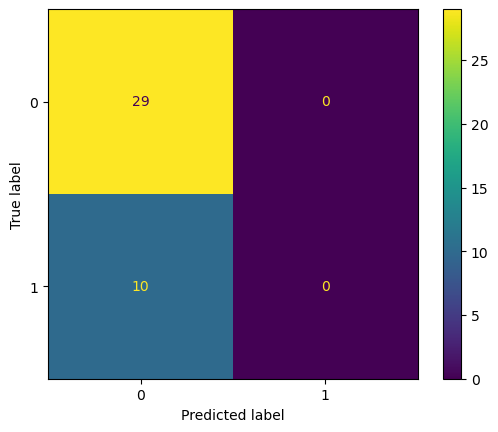

In [24]:
#docs_infra: no_execute
if numero_clases==2:
    classes = [0, 1]
else:   
    classes = [0, 1, 2, 3, 4]
#classes = [0, 1]
cm=confusion_matrix(y_test_def2, y_pred2,labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [25]:
from sklearn.metrics import classification_report
if numero_clases==2:
    target_names = ['Buenos', 'Malos']
else:   
    target_names = ['A', 'B+', 'B', 'B-','C']
print(classification_report(y_test_def2, y_pred2, target_names=target_names, digits=4))

              precision    recall  f1-score   support

      Buenos     0.7436    1.0000    0.8529        29
       Malos     0.0000    0.0000    0.0000        10

    accuracy                         0.7436        39
   macro avg     0.3718    0.5000    0.4265        39
weighted avg     0.5529    0.7436    0.6342        39



c:\Users\rgadea\AppData\Local\miniconda3\envs\tensorflow_gpu_2024\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rgadea\AppData\Local\miniconda3\envs\tensorflow_gpu_2024\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\rgadea\AppData\Local\miniconda3\envs\tensorflow_gpu_2024\lib\site-packages\sklearn\metrics\_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this 

In [26]:
# model.save('modelos/modelote1203_200')  # creates a HDF5 file 'my_model.h5'

In [27]:
#model.save('idea.h5')  # creates a HDF5 file 'my_model.h5'
model.save('modelos\modelo_perfecto_{}_{}.h5'.format(experimento,datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))) 